# Error Analysis

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from collections import Counter
from data_loader import load_clinc

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

data = load_clinc(use_sample=False)
test_labels = data['test_labels']
num_classes = data['num_classes']

label_names_map = {}
with open('data/train_sample.jsonl') as f:
    for line in f:
        obj = json.loads(line)
        label_names_map[obj['label']] = obj['label_text']
label_names = [label_names_map[i] for i in range(len(label_names_map))]

def load_preds(filepath, key='predictions'):
    with open(filepath) as f:
        data = json.load(f)
    if 'runs' in data:
        runs = data['runs']
        f1s = [r['test_metrics']['macro_f1'] for r in runs]
        median_idx = np.argsort(f1s)[len(f1s)//2]
        return runs[median_idx][key]
    return data[key]

methods_lr = {
    'Baseline': 'results/results_lr_baseline.json',
    'Grid Search': 'results/results_lr_grid.json',
    'Random Search': 'results/results_lr_random.json',
    'GA': 'results/results_lr_ga.json',
    'Hybrid': 'results/results_lr_hybrid.json',
}

methods_lstm = {
    'Baseline': 'results/results_lstm_baseline.json',
    'Grid Search': 'results/results_lstm_grid.json',
    'Random Search': 'results/results_lstm_random.json',
    'GA': 'results/results_lstm_ga.json',
    'Hybrid': 'results/results_lstm_hybrid.json',
}

lr_preds = {}
for name, path in methods_lr.items():
    if os.path.exists(path):
        try:
            lr_preds[name] = load_preds(path)
        except (KeyError, IndexError):
            print(f"Warning: no predictions in {path}")

lstm_preds = {}
for name, path in methods_lstm.items():
    if os.path.exists(path):
        try:
            lstm_preds[name] = load_preds(path)
        except (KeyError, IndexError):
            print(f"Warning: no predictions in {path}")

print(f"LR methods loaded: {list(lr_preds.keys())}")
print(f"LSTM methods loaded: {list(lstm_preds.keys())}")

15250 / 3100 / 5500, 151 classes (full)
LR methods loaded: ['Baseline', 'Grid Search', 'Random Search', 'GA', 'Hybrid']
LSTM methods loaded: ['Baseline', 'Grid Search', 'Random Search', 'GA', 'Hybrid']


## 1. Confusion Matrix

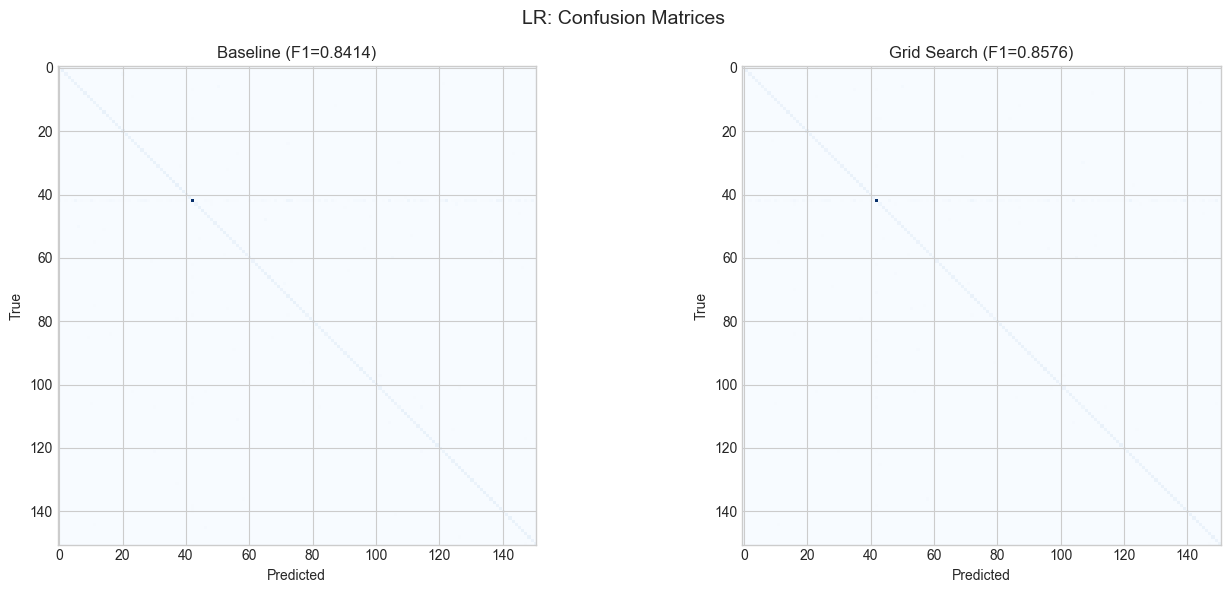

In [2]:
def plot_confusion_matrix(true_labels, pred_labels, title, ax):
    cm = confusion_matrix(true_labels, pred_labels)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    return im

if lr_preds:
    lr_methods_to_show = ['Baseline']
    best_method = max(
        [m for m in lr_preds if m != 'Baseline'],
        key=lambda m: f1_score(test_labels, lr_preds[m], average='macro', zero_division=0),
        default=None
    )
    if best_method:
        lr_methods_to_show.append(best_method)

    fig, axes = plt.subplots(1, len(lr_methods_to_show), figsize=(7*len(lr_methods_to_show), 6))
    if len(lr_methods_to_show) == 1:
        axes = [axes]
    for ax, method in zip(axes, lr_methods_to_show):
        f1 = f1_score(test_labels, lr_preds[method], average='macro', zero_division=0)
        plot_confusion_matrix(test_labels, lr_preds[method], f'{method} (F1={f1:.4f})', ax)
    plt.suptitle('LR: Confusion Matrices', fontsize=14)
    plt.tight_layout()
    plt.savefig('results/error_confusion_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. Per-class F1 Analysis

LR: Baseline vs Grid Search
  Improved (>1%): 82 classes
  Degraded (>1%): 44 classes
  Unchanged:25 classes


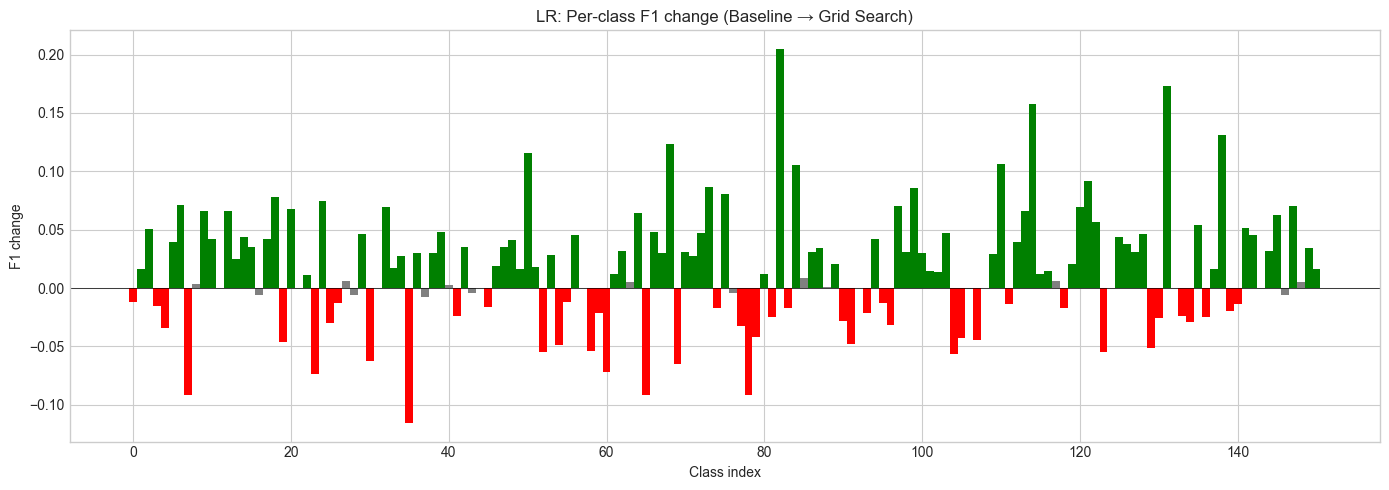


Top 5 most degraded classes:
  balance                       : 0.8788 → 0.7632 (-0.1156)
  interest_rate                 : 0.8852 → 0.7931 (-0.0921)
  distance                      : 0.7143 → 0.6230 (-0.0913)
  todo_list_update              : 0.8056 → 0.7143 (-0.0913)
  restaurant_reservation        : 0.8615 → 0.7879 (-0.0736)


In [3]:
def per_class_f1(true_labels, pred_labels):
    from sklearn.metrics import f1_score as f1
    classes = sorted(set(true_labels))
    return {c: round(f1(
        [1 if t == c else 0 for t in true_labels],
        [1 if p == c else 0 for p in pred_labels],
        zero_division=0
    ), 4) for c in classes}

if lr_preds and 'Baseline' in lr_preds and best_method:
    baseline_pcf1 = per_class_f1(test_labels, lr_preds['Baseline'])
    best_pcf1 = per_class_f1(test_labels, lr_preds[best_method])

    classes = sorted(baseline_pcf1.keys())
    diff = [best_pcf1[c] - baseline_pcf1[c] for c in classes]

    improved = sum(1 for d in diff if d > 0.01)
    degraded = sum(1 for d in diff if d < -0.01)
    unchanged = len(diff) - improved - degraded

    print(f"LR: Baseline vs {best_method}")
    print(f"  Improved (>1%): {improved} classes")
    print(f"  Degraded (>1%): {degraded} classes")
    print(f"  Unchanged:{unchanged} classes")

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['green' if d > 0.01 else 'red' if d < -0.01 else 'gray' for d in diff]
    ax.bar(range(len(diff)), diff, color=colors, width=1.0)
    ax.set_xlabel('Class index')
    ax.set_ylabel('F1 change')
    ax.set_title(f'LR: Per-class F1 change (Baseline \u2192 {best_method})')
    ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('results/error_perclass_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

    sorted_diff = sorted(zip(classes, diff), key=lambda x: x[1])
    print("\nTop 5 most degraded classes:")
    for cls, d in sorted_diff[:5]:
        print(f"  {label_names[cls]:30s}: {baseline_pcf1[cls]:.4f} \u2192 {best_pcf1[cls]:.4f} ({d:+.4f})")

## 3. OOS Class Analysis

In [4]:
oos_idx = label_names.index('oos') if 'oos' in label_names else None

if oos_idx is not None:
    print(f"OOS class index: {oos_idx}")
    print(f"OOS test samples: {test_labels.count(oos_idx)}")

    print("\nLR: OOS F1 by method")
    for method, preds in lr_preds.items():
        oos_f1_val = f1_score(
            [1 if t == oos_idx else 0 for t in test_labels],
            [1 if p == oos_idx else 0 for p in preds],
            zero_division=0
        )
        macro_f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)

        non_oos_true = [t for t in test_labels if t != oos_idx]
        non_oos_pred = [p for t, p in zip(test_labels, preds) if t != oos_idx]
        macro_f1_no_oos = f1_score(non_oos_true, non_oos_pred, average='macro', zero_division=0)

        print(f"  {method:15s}: OOS F1={oos_f1_val:.4f}, Macro F1 (all)={macro_f1_all:.4f}, Macro F1 (no OOS)={macro_f1_no_oos:.4f}")

    print("\nLSTM: OOS F1 by method")
    for method, preds in lstm_preds.items():
        oos_f1_val = f1_score(
            [1 if t == oos_idx else 0 for t in test_labels],
            [1 if p == oos_idx else 0 for p in preds],
            zero_division=0
        )
        macro_f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)

        non_oos_true = [t for t in test_labels if t != oos_idx]
        non_oos_pred = [p for t, p in zip(test_labels, preds) if t != oos_idx]
        macro_f1_no_oos = f1_score(non_oos_true, non_oos_pred, average='macro', zero_division=0)

        print(f"  {method:15s}: OOS F1={oos_f1_val:.4f}, Macro F1 (all)={macro_f1_all:.4f}, Macro F1 (no OOS)={macro_f1_no_oos:.4f}")

OOS class index: 42
OOS test samples: 1000

LR: OOS F1 by method
  Baseline       : OOS F1=0.5675, Macro F1 (all)=0.8414, Macro F1 (no OOS)=0.8877
  Grid Search    : OOS F1=0.6026, Macro F1 (all)=0.8576, Macro F1 (no OOS)=0.9008
  Random Search  : OOS F1=0.6026, Macro F1 (all)=0.8576, Macro F1 (no OOS)=0.9008
  GA             : OOS F1=0.6026, Macro F1 (all)=0.8576, Macro F1 (no OOS)=0.9008
  Hybrid         : OOS F1=0.6026, Macro F1 (all)=0.8576, Macro F1 (no OOS)=0.9008

LSTM: OOS F1 by method
  Baseline       : OOS F1=0.6721, Macro F1 (all)=0.8433, Macro F1 (no OOS)=0.8787
  Grid Search    : OOS F1=0.7019, Macro F1 (all)=0.8727, Macro F1 (no OOS)=0.9068
  Random Search  : OOS F1=0.6763, Macro F1 (all)=0.8598, Macro F1 (no OOS)=0.8970
  GA             : OOS F1=0.7064, Macro F1 (all)=0.8681, Macro F1 (no OOS)=0.9005
  Hybrid         : OOS F1=0.7019, Macro F1 (all)=0.8727, Macro F1 (no OOS)=0.9068


In [5]:
error_data = {"test_labels": [int(x) for x in test_labels]}

error_data["lr_per_class_f1"] = {}
for method, preds in lr_preds.items():
    error_data["lr_per_class_f1"][method] = per_class_f1(test_labels, preds)

error_data["lstm_per_class_f1"] = {}
for method, preds in lstm_preds.items():
    error_data["lstm_per_class_f1"][method] = per_class_f1(test_labels, preds)

if oos_idx is not None:
    error_data["oos_idx"] = oos_idx
    error_data["oos_metrics"] = {"lr": {}, "lstm": {}}

    for method, preds in lr_preds.items():
        oos_f1_val = f1_score(
            [1 if t == oos_idx else 0 for t in test_labels],
            [1 if p == oos_idx else 0 for p in preds],
            zero_division=0
        )
        macro_f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)
        non_oos_true = [t for t in test_labels if t != oos_idx]
        non_oos_pred = [p for t, p in zip(test_labels, preds) if t != oos_idx]
        macro_f1_no_oos = f1_score(non_oos_true, non_oos_pred, average='macro', zero_division=0)
        error_data["oos_metrics"]["lr"][method] = {
            "oos_f1": round(oos_f1_val, 4),
            "macro_f1_all": round(macro_f1_all, 4),
            "macro_f1_no_oos": round(macro_f1_no_oos, 4)
        }

    for method, preds in lstm_preds.items():
        oos_f1_val = f1_score(
            [1 if t == oos_idx else 0 for t in test_labels],
            [1 if p == oos_idx else 0 for p in preds],
            zero_division=0
        )
        macro_f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)
        non_oos_true = [t for t in test_labels if t != oos_idx]
        non_oos_pred = [p for t, p in zip(test_labels, preds) if t != oos_idx]
        macro_f1_no_oos = f1_score(non_oos_true, non_oos_pred, average='macro', zero_division=0)
        error_data["oos_metrics"]["lstm"][method] = {
            "oos_f1": round(oos_f1_val, 4),
            "macro_f1_all": round(macro_f1_all, 4),
            "macro_f1_no_oos": round(macro_f1_no_oos, 4)
        }

with open('results/error_analysis.json', 'w') as f:
    json.dump(error_data, f, indent=4, default=str)

print("Saved: results/error_analysis.json")

Saved: results/error_analysis.json
